<a href="https://colab.research.google.com/github/Ymilagros/telecomx-churn-etl/blob/views/notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TelecomX — ETL + EDA de Churn (Evasión de clientes)

**Objetivo:** extraer datos (API/JSON), transformar/limpiar y analizar (EDA) para detectar factores asociados a la pérdida de clientes.


In [2]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
print("✅ Librerías listas")


✅ Librerías listas


In [5]:
import pandas as pd

# URL cruda del JSON en tu repo
url = "https://raw.githubusercontent.com/Ymilagros/telecomx-churn-etl/refs/heads/views/data/TelecomX_Data.json"

# Leer los datos
df = pd.read_json(url)

# Ver forma y primeras filas
print("Filas y columnas:", df.shape)
df.head()


Filas y columnas: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [7]:
print("Columnas en df:", list(df.columns))
for col in df.columns:
    print(f"{col:12} → tipo del primer valor:", type(df[col].iloc[0]))


Columnas en df: ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']
customerID   → tipo del primer valor: <class 'str'>
Churn        → tipo del primer valor: <class 'str'>
customer     → tipo del primer valor: <class 'dict'>
phone        → tipo del primer valor: <class 'dict'>
internet     → tipo del primer valor: <class 'dict'>
account      → tipo del primer valor: <class 'dict'>


In [8]:
import pandas as pd

# Normalizar cada columna anidada
customer_df = pd.json_normalize(df['customer'])
phone_df    = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df  = pd.json_normalize(df['account'])

# Unir todo en un único DataFrame
df_final = pd.concat(
    [df[['customerID','Churn']], customer_df, phone_df, internet_df, account_df],
    axis=1
)

# Revisar resultado
print("Filas y columnas después de normalizar:", df_final.shape)
df_final.head()


Filas y columnas después de normalizar: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
# Info general
df_final.info()

# Valores nulos
print("\nValores nulos por columna:\n", df_final.isnull().sum())

# Valores únicos por columna
print("\nValores únicos por columna:\n", df_final.nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [10]:
# Estadísticas numéricas
df_final.describe()

# Estadísticas categóricas
df_final.describe(include="object")


,customerID,Churn,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Total
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


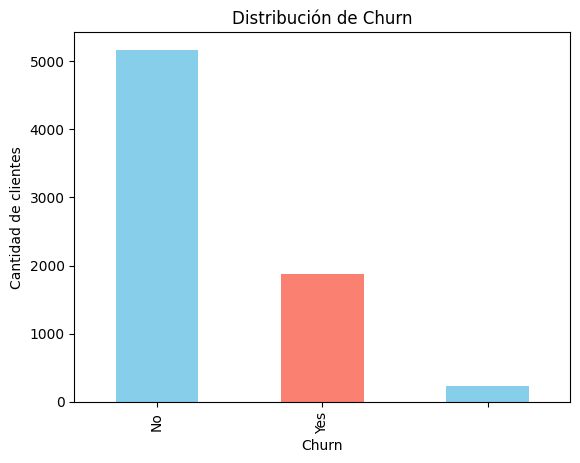

In [11]:
import matplotlib.pyplot as plt

df_final['Churn'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()


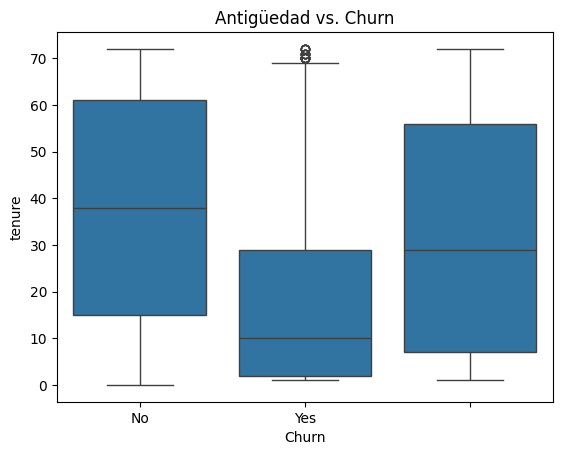

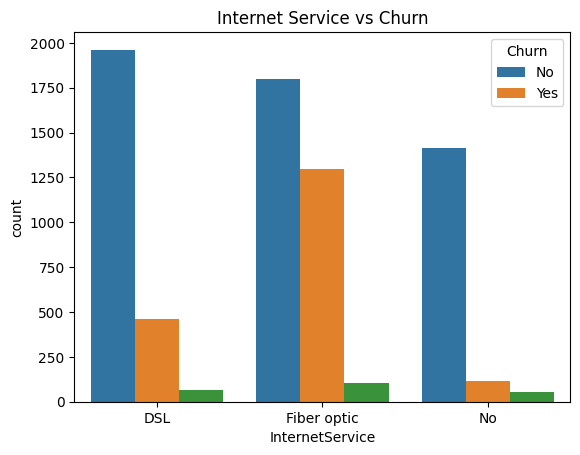

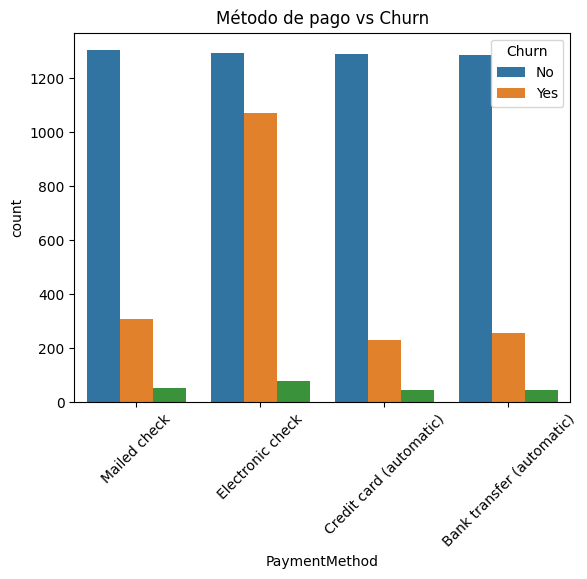

In [12]:
import seaborn as sns

# Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df_final)
plt.title("Antigüedad vs. Churn")
plt.show()

# InternetService vs Churn
sns.countplot(x="InternetService", hue="Churn", data=df_final)
plt.title("Internet Service vs Churn")
plt.show()

# PaymentMethod vs Churn
sns.countplot(x="PaymentMethod", hue="Churn", data=df_final)
plt.title("Método de pago vs Churn")
plt.xticks(rotation=45)
plt.show()


In [13]:
# 1. Vista general
print("Dimensiones:", df_final.shape)
print("\nTipos de datos:\n", df_final.dtypes)

# 2. Valores nulos
print("\nValores nulos por columna:\n", df_final.isnull().sum())

# 3. Variables categóricas y sus valores únicos
for col in df_final.select_dtypes(include="object").columns:
    print(f"\nColumna: {col}")
    print(df_final[col].value_counts().head())

# 4. Estadísticas numéricas
print("\nEstadísticas numéricas:\n", df_final.describe())


Dimensiones: (7267, 21)

Tipos de datos:
 customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object

Valores nulos por columna:
 customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV        

/tmp/ipython-input-2951515942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df_final, palette="Set2")


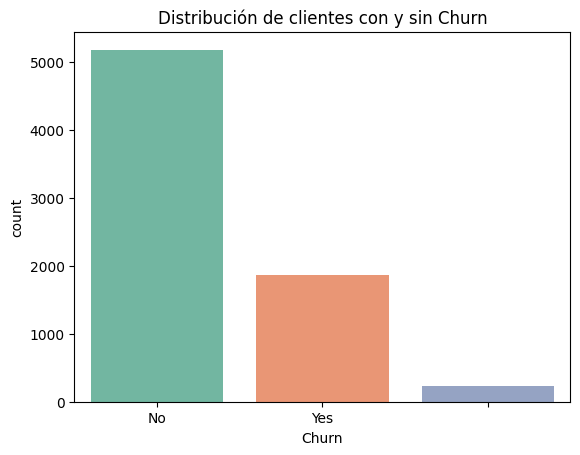

/tmp/ipython-input-2951515942.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="tenure", data=df_final, palette="Set3")


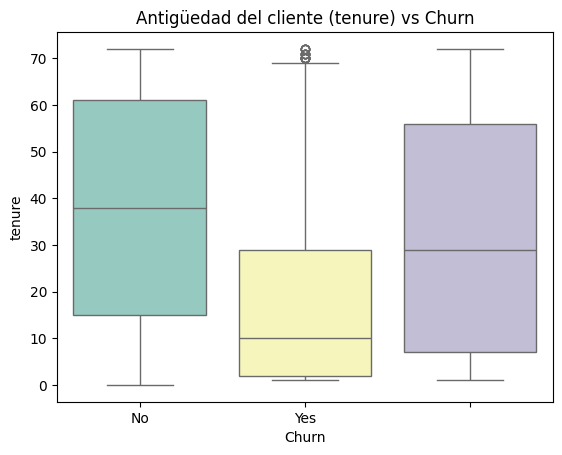

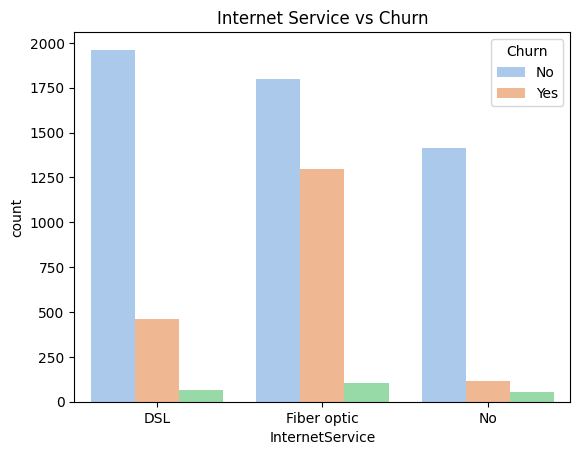

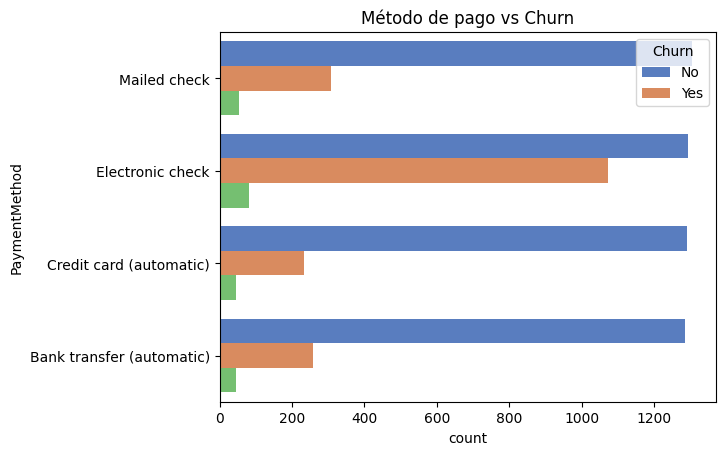

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribución de Churn
sns.countplot(x="Churn", data=df_final, palette="Set2")
plt.title("Distribución de clientes con y sin Churn")
plt.show()

# Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df_final, palette="Set3")
plt.title("Antigüedad del cliente (tenure) vs Churn")
plt.show()

# InternetService vs Churn
sns.countplot(x="InternetService", hue="Churn", data=df_final, palette="pastel")
plt.title("Internet Service vs Churn")
plt.show()

# PaymentMethod vs Churn
sns.countplot(y="PaymentMethod", hue="Churn", data=df_final, palette="muted")
plt.title("Método de pago vs Churn")
plt.show()


In [15]:
import numpy as np
import pandas as pd

# Partimos del df_final que ya tienes
df_clean = df_final.copy()

# 4.1) Normalizar nombres (snake_case)
def snake(s):
    return (str(s).replace(" ", "_").replace("-", "_").replace("/", "_").replace(".", "_").lower().strip())

df_clean.columns = [snake(c) for c in df_clean.columns]

# 4.2) Crear columna objetivo binaria (churn_flag: 1=Yes, 0=No)
if "churn" in df_clean.columns:
    df_clean["churn_flag"] = df_clean["churn"].astype(str).str.strip().str.lower().map({"yes":1, "no":0})
else:
    # Si no existe churn (no debería pasar en tu dataset), la creamos en 0
    df_clean["churn_flag"] = 0

# 4.3) Detectar y estandarizar columnas de cargos
# (hay datasets donde aparecen como charges_monthly / monthlycharges, etc.)
def find_like(cols, must_have):
    must = [m.lower() for m in must_have]
    for c in cols:
        low = c.lower()
        if all(m in low for m in must):
            return c
    return None

monthly_col = find_like(df_clean.columns, ["charge","month"]) or find_like(df_clean.columns, ["monthly","charge"])
total_col   = find_like(df_clean.columns, ["charge","total"]) or find_like(df_clean.columns, ["total","charge"])

if monthly_col and "monthly_charges" not in df_clean.columns:
    df_clean["monthly_charges"] = pd.to_numeric(df_clean[monthly_col], errors="coerce")
if total_col and "total_charges" not in df_clean.columns:
    df_clean["total_charges"] = pd.to_numeric(df_clean[total_col], errors="coerce")

# 4.4) Casting de numéricos típicos
for c in ["seniorcitizen", "tenure", "monthly_charges", "total_charges"]:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# 4.5) Mapear columnas Yes/No a 0/1 cuando aplique
yesno_cols = [c for c in df_clean.columns if df_clean[c].dtype == "object"
              and df_clean[c].astype(str).str.lower().isin(["yes","no"]).any()]

def yn_to_01(x):
    s = str(x).strip().lower()
    if s in ("yes","si","true","1"): return 1
    if s in ("no","false","0"): return 0
    return np.nan

for c in yesno_cols:
    df_clean[c] = df_clean[c].map(yn_to_01)

# 4.6) Manejo de nulos básico
for c in df_clean.columns:
    if df_clean[c].dtype.kind in "biufc":  # numéricos
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())
    else:                                   # categóricos (si quedaran)
        df_clean[c] = df_clean[c].fillna("unknown")

# 4.7) Features útiles
# - Conteo de servicios contratados (suma de columnas binarias de servicios)
service_cols = [c for c in df_clean.columns if c in [
    "phoneservice","multiplelines","onlinesecurity","onlinebackup",
    "deviceprotection","techsupport","streamingtv","streamingmovies"
]]
if service_cols:
    df_clean["service_count"] = df_clean[service_cols].sum(axis=1)
else:
    df_clean["service_count"] = np.nan

# - Buckets de permanencia (tenure)
if "tenure" in df_clean.columns:
    df_clean["tenure_bucket"] = pd.cut(df_clean["tenure"],
        bins=[-1,6,12,24,48,120], labels=["0-6","7-12","13-24","25-48","49+"]
    )

print("✅ Limpieza/estandarización lista. Shape:", df_clean.shape)
df_clean.head()


✅ Limpieza/estandarización lista. Shape: (7267, 26)


,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,churn_flag,monthly_charges,total_charges,service_count,tenure_bucket
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.3,0.0,65.6,593.30,4.0,7-12
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.4,0.0,59.9,542.40,3.0,7-12
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,1.0,73.9,280.85,2.0,0-6
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,1.0,98.0,1237.85,5.0,13-24
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.4,1.0,83.9,267.40,3.0,0-6


In [16]:
import os
out_path = "/content/telecomx_churn_clean.csv"
df_clean.to_csv(out_path, index=False)
print("💾 Guardado:", out_path)

# (opcional) descargar a tu PC
# from google.colab import files
# files.download(out_path)


💾 Guardado: /content/telecomx_churn_clean.csv


In [17]:
print("Dimensiones:", df_clean.shape)
print("\nTipos de datos:\n", df_clean.dtypes.head(20))
print("\nNulos por columna (top 15):\n", df_clean.isna().sum().sort_values(ascending=False).head(15))

# Distribución de churn
if "churn_flag" in df_clean.columns:
    churn_pct = df_clean["churn_flag"].mean()*100
    print(f"\nTasa global de churn: {churn_pct:.2f}%")
else:
    print("\n⚠️ No se encontró churn_flag")

# Estadísticas numéricas principales
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[num_cols].describe().T.head(12)


Dimensiones: (7267, 26)

Tipos de datos:
 customerid           object
churn               float64
gender               object
seniorcitizen         int64
partner               int64
dependents            int64
tenure                int64
phoneservice          int64
multiplelines       float64
internetservice     float64
onlinesecurity      float64
onlinebackup        float64
deviceprotection    float64
techsupport         float64
streamingtv         float64
streamingmovies     float64
contract             object
paperlessbilling      int64
paymentmethod        object
charges_monthly     float64
dtype: object

Nulos por columna (top 15):
 customerid          0
churn               0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
dtype: int64

Tasa globa

,count,mean,std,min,25%,50%,75%,max
churn,7267.0,0.257190,0.437115,0.0,0.0,0.0,1.0,1.0
seniorcitizen,7267.0,0.162653,0.369074,0.0,0.0,0.0,0.0,1.0
partner,7267.0,0.484106,0.499782,0.0,0.0,0.0,1.0,1.0
dependents,7267.0,0.300124,0.458343,0.0,0.0,0.0,1.0,1.0
tenure,7267.0,32.346498,24.571773,0.0,9.0,29.0,55.0,72.0
phoneservice,7267.0,0.902711,0.296371,0.0,1.0,1.0,1.0,1.0
multiplelines,7267.0,0.421770,0.493876,0.0,0.0,0.0,1.0,1.0
internetservice,7267.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
onlinesecurity,7267.0,0.285950,0.451897,0.0,0.0,0.0,1.0,1.0
onlinebackup,7267.0,0.344571,0.475261,0.0,0.0,0.0,1.0,1.0


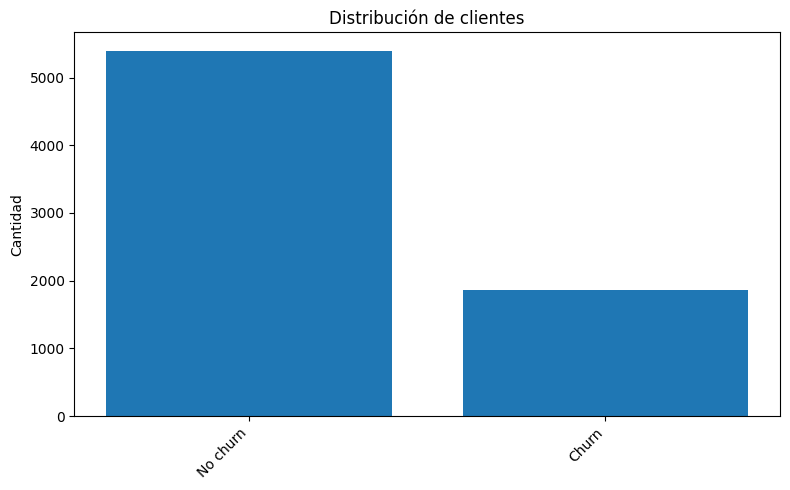


Churn por contrato (%):
 contract
Month-to-month    41.323346
One year          10.928242
Two year           2.753873
Name: churn_flag, dtype: float64


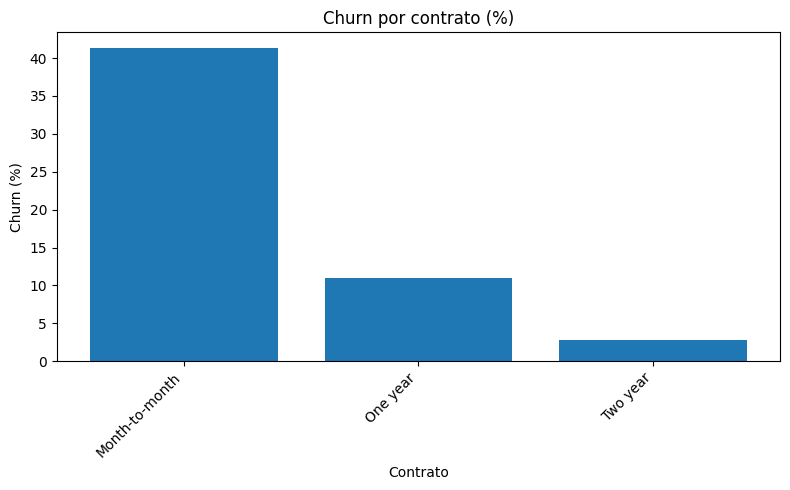


Churn por método de pago (%):
 paymentmethod
Electronic check             43.803681
Mailed check                 18.498498
Bank transfer (automatic)    16.236627
Credit card (automatic)      14.795918
Name: churn_flag, dtype: float64


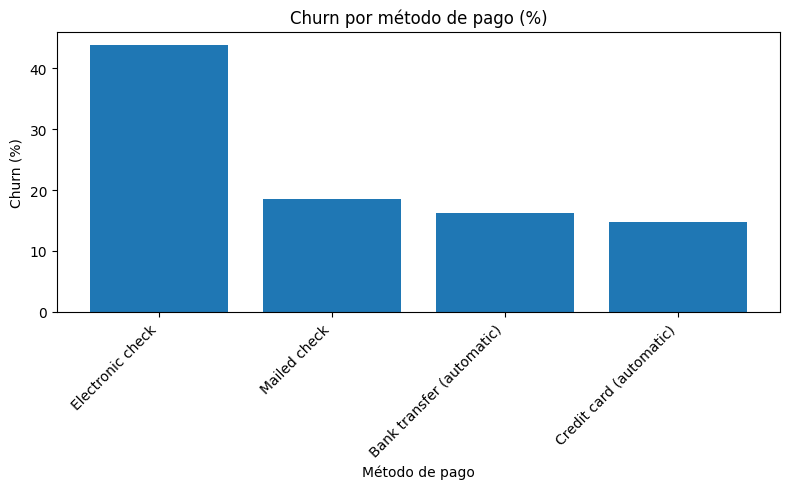


Churn por permanencia (%):
 tenure_bucket
0-6      51.041667
7-12     34.705075
13-24    28.133971
25-48    19.720874
49+       9.224773
Name: churn_flag, dtype: float64


/tmp/ipython-input-4131754789.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100)


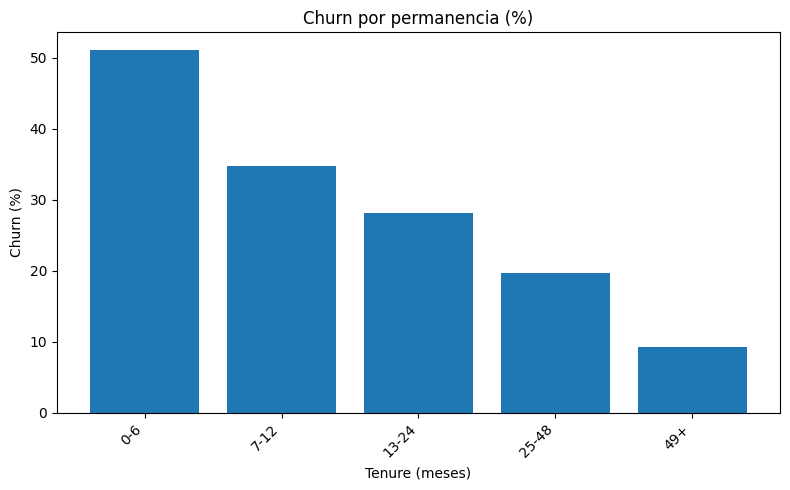

In [18]:
import matplotlib.pyplot as plt

def barplot_series(idx, vals, title, xlabel, ylabel):
    plt.figure(figsize=(8,5))
    plt.bar(idx, vals)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 7.1) Churn global
vc = df_clean["churn_flag"].value_counts().sort_index()
barplot_series(["No churn","Churn"], [vc.get(0,0), vc.get(1,0)],
               "Distribución de clientes", "", "Cantidad")

# 7.2) Churn por tipo de contrato (si existe)
if "contract" in df_clean.columns:
    grp = df_clean.groupby("contract")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    print("\nChurn por contrato (%):\n", grp)
    barplot_series(grp.index.astype(str), grp.values, "Churn por contrato (%)", "Contrato", "Churn (%)")

# 7.3) Churn por método de pago (si existe)
if "paymentmethod" in df_clean.columns:
    grp = df_clean.groupby("paymentmethod")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    print("\nChurn por método de pago (%):\n", grp)
    barplot_series(grp.index.astype(str), grp.values, "Churn por método de pago (%)", "Método de pago", "Churn (%)")

# 7.4) Churn por permanencia (tenure_bucket)
if "tenure_bucket" in df_clean.columns:
    grp = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100)
    print("\nChurn por permanencia (%):\n", grp)
    barplot_series(grp.index.astype(str), grp.values, "Churn por permanencia (%)", "Tenure (meses)", "Churn (%)")


In [19]:
insights = []

# contrato
if "contract" in df_clean.columns:
    c = df_clean.groupby("contract")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    if len(c): insights.append(f"• Mayor churn en contrato **{c.index[0]}** ({c.iloc[0]:.1f}%).")

# método de pago
if "paymentmethod" in df_clean.columns:
    p = df_clean.groupby("paymentmethod")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    if len(p): insights.append(f"• Método de pago con mayor churn: **{p.index[0]}** ({p.iloc[0]:.1f}%).")

# permanencia
if "tenure_bucket" in df_clean.columns:
    t = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    if len(t): insights.append(f"• Mayor churn en clientes con **{t.index[0]}** meses de permanencia.")

# cargos
if {"monthly_charges","churn_flag"}.issubset(df_clean.columns):
    means = df_clean.groupby("churn_flag")["monthly_charges"].mean()
    if means.get(1, np.nan) > means.get(0, np.nan):
        insights.append("• Quienes se dan de baja pagan **más** por mes (posible sensibilidad al precio).")
    else:
        insights.append("• Quienes se dan de baja pagan **menos** por mes (posible bajo valor percibido).")

print("### Insights clave")
for s in insights: print(s)


### Insights clave
• Mayor churn en contrato **Month-to-month** (41.3%).
• Método de pago con mayor churn: **Electronic check** (43.8%).
• Mayor churn en clientes con **0-6** meses de permanencia.
• Quienes se dan de baja pagan **más** por mes (posible sensibilidad al precio).


/tmp/ipython-input-347573715.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100).sort_values(ascending=False)


In [20]:
import numpy as np

res = {}

# tamaño
res["filas"] = len(df_clean)
res["columnas"] = df_clean.shape[1]

# churn
res["tasa_churn_%"] = round(df_clean["churn_flag"].mean()*100, 2)

# top contrato (si existe)
if "contract" in df_clean.columns:
    c = df_clean.groupby("contract")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    res["contrato_mayor_churn"] = f"{c.index[0]} ({c.iloc[0]:.1f}%)"

# top método de pago (si existe)
if "paymentmethod" in df_clean.columns:
    p = df_clean.groupby("paymentmethod")["churn_flag"].mean().mul(100).sort_values(ascending=False)
    res["pago_mayor_churn"] = f"{p.index[0]} ({p.iloc[0]:.1f}%)"

# churn por permanencia (si existe)
if "tenure_bucket" in df_clean.columns:
    t = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100)
    res["permanencia_peor_bucket"] = f"{t.sort_values(ascending=False).index[0]}"

# cargos mensuales promedio por estado
if {"monthly_charges","churn_flag"}.issubset(df_clean.columns):
    m = df_clean.groupby("churn_flag")["monthly_charges"].mean()
    res["cargos_mes_no_churn"] = round(m.get(0, np.nan), 2)
    res["cargos_mes_churn"] = round(m.get(1, np.nan), 2)

print("✅ Resumen para informe:\n")
for k,v in res.items():
    print(f"- {k}: {v}")


✅ Resumen para informe:

- filas: 7267
- columnas: 26
- tasa_churn_%: 25.72
- contrato_mayor_churn: Month-to-month (41.3%)
- pago_mayor_churn: Electronic check (43.8%)
- permanencia_peor_bucket: 0-6
- cargos_mes_no_churn: 61.35
- cargos_mes_churn: 74.44


/tmp/ipython-input-3283724619.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df_clean.groupby("tenure_bucket")["churn_flag"].mean().mul(100)


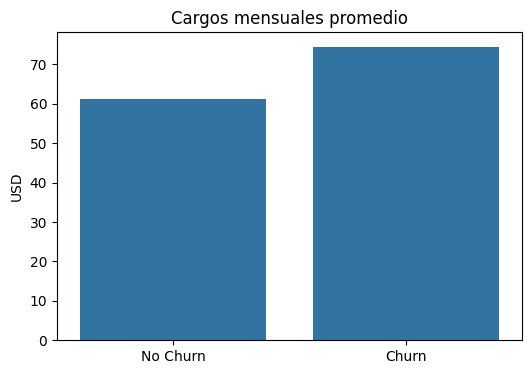

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x=["No Churn","Churn"], y=[61.35, 74.44])
plt.title("Cargos mensuales promedio")
plt.ylabel("USD")
plt.show()
